In [9]:
from catboost import CatBoostRegressor
import numpy as np
import optuna
import pandas as pd

In [2]:
from restaurant_visitor_eda.config import PROCESSED_DATA_DIR

df_train = pd.read_csv(PROCESSED_DATA_DIR / "train_features.csv", parse_dates=["visit_date"])
df_test = pd.read_csv(PROCESSED_DATA_DIR / "test_features.csv", parse_dates=["visit_date"])

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")

2026-06-25 11:57:09.723 | INFO     | restaurant_visitor_eda.config:<module>:11 - PROJ_ROOT path is: /home/alxdrzd/alxdrzd/ds-projects/restaurant-visitor-eda


Train shape: (252108, 28)
Test shape: (32019, 28)


In [3]:
from restaurant_visitor_eda.features import binary_features, categorical_features, numeric_features

features = categorical_features + numeric_features + binary_features

X_full = df_train[features]
y_full = np.log1p(df_train["visitors"].values)

In [4]:
from restaurant_visitor_eda.features import get_custom_cv_splits

cv_splits = get_custom_cv_splits(df_train, n_splits=3, val_days=39)

Fold 1: Train ends 2017-03-14| Val: 2017-03-15 to 2017-04-22
Fold 2: Train ends 2017-02-03| Val: 2017-02-04 to 2017-03-14
Fold 3: Train ends 2016-12-26| Val: 2016-12-27 to 2017-02-03


In [5]:
from optuna_integration.catboost import CatBoostPruningCallback


def objective(trial: optuna.trial.Trial) -> float:
    params = {
        "iterations": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 5, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 25.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.1, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "random_seed": 42,
        "od_type": "Iter",
        "od_wait": 50,
        "verbose": False,
    }

    pruning_callback = CatBoostPruningCallback(trial, "RMSE")
    cv_scores = []
    fold_iters = []

    for fold, (train_idx, val_idx) in enumerate(cv_splits):
        X_train, y_train = X_full.iloc[train_idx], y_full[train_idx]
        X_val, y_val = X_full.iloc[val_idx], y_full[val_idx]

        model = CatBoostRegressor(**params, cat_features=categorical_features)

        if fold == 0:
            model.fit(X_train, y_train, eval_set=(X_val, y_val), callbacks=[pruning_callback])
            pruning_callback.check_pruned()
        else:
            model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=100)

        best_score = model.get_best_score()["validation"]["RMSE"]
        best_iter = model.get_best_iteration()

        cv_scores.append(best_score)
        fold_iters.append(best_iter)

    trial.set_user_attr("mean_best_iter", int(np.mean(fold_iters)))

    return np.mean(cv_scores)

In [6]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow_tracking.db")
mlflow.set_experiment("CatBoost_Optuna_Tuning")

with mlflow.start_run(run_name="optuna_search_with_pruning"):
    pruner = optuna.pruners.MedianPruner(n_warmup_steps=50)
    study = optuna.create_study(direction="minimize", pruner=pruner)

    study.optimize(objective, n_trials=50, show_progress_bar=True)

    mlflow.log_params(study.best_params)
    mlflow.log_metric("best_cv_rmse", study.best_value)
    mlflow.log_metric("mean_best_iter", study.best_trial.user_attrs["mean_best_iter"])

    print(f"\n Best RMSE: {study.best_value:.4f}")

[I 2026-06-25 11:57:12,072] A new study created in memory with name: no-name-4ca0f121-69ef-4b56-bdb3-8b40b100ca10


  0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipykernel_6156/3994838544.py:20: ExperimentalWarning: CatBoostPruningCallback is experimental (supported from v3.0.0). The interface can change in the future.
  pruning_callback = CatBoostPruningCallback(trial, "RMSE")


[I 2026-06-25 11:58:14,411] Trial 0 finished with value: 0.5086606824649477 and parameters: {'learning_rate': 0.03565376700239586, 'depth': 6, 'l2_leaf_reg': 18.39742770013812, 'random_strength': 0.5581706736472467, 'bagging_temperature': 0.5307864843825578}. Best is trial 0 with value: 0.5086606824649477.
[I 2026-06-25 11:59:55,979] Trial 1 finished with value: 0.5082634028085288 and parameters: {'learning_rate': 0.04065824191437317, 'depth': 9, 'l2_leaf_reg': 5.379226194508048, 'random_strength': 2.4083666937131225, 'bagging_temperature': 0.5650192370687505}. Best is trial 1 with value: 0.5082634028085288.
[I 2026-06-25 12:00:55,398] Trial 2 finished with value: 0.5084810480853107 and parameters: {'learning_rate': 0.04033628512104195, 'depth': 7, 'l2_leaf_reg': 2.5184539582714236, 'random_strength': 0.1338616600623699, 'bagging_temperature': 0.4507586170144826}. Best is trial 1 with value: 0.5082634028085288.
[I 2026-06-25 12:02:45,382] Trial 3 finished with value: 0.5089484316709355

In [7]:
print("\n--- BEST PARAMS ---")
for key, value in study.best_params.items():
    print(f"{key}: {value}")
print(f"\n best rmsle during CV: {study.best_value:.4f}")

optimal_iterations = study.best_trial.user_attrs["mean_best_iter"]
print(f"Optimal Iter: {optimal_iterations}")


--- BEST PARAMS ---
learning_rate: 0.09770744696141544
depth: 10
l2_leaf_reg: 4.937492551541292
random_strength: 1.4517872521559325
bagging_temperature: 0.02250835288061509

 best rmsle during CV: 0.5069
Optimal Iter: 108


In [8]:
final_params = study.best_params.copy()
final_params["iterations"] = optimal_iterations * 1.5
final_params["loss_function"] = "RMSE"
final_params["eval_metric"] = "RMSE"
final_params["random_seed"] = 42
final_params["learning_rate"] = final_params["learning_rate"] / 1.5

final_model = CatBoostRegressor(**final_params, cat_features=categorical_features)

final_model.fit(X_full, y_full, verbose=100)

0:	learn: 0.7802290	total: 50.3ms	remaining: 8.1s
100:	learn: 0.5123416	total: 3.97s	remaining: 2.4s
161:	learn: 0.5049146	total: 6.34s	remaining: 0us


CatBoostRegressor(bagging_temperature=0.02250835288061509, cat_features=['air_store_id', 'air_genre_name', 'day_of_week', 'month', 'day_pattern', 'prefecture', 'district', 'block'], depth=10, eval_metric='RMSE', iterations=162.0, l2_leaf_reg=4.937492551541292, learning_rate=0.06513829797427696, loss_function='RMSE', random_seed=42, random_strength=1.4517872521559325)

In [9]:
X_test = df_test[features]

preds_log = final_model.predict(X_test)

preds_real_clipped = np.clip(np.expm1(preds_log), 1.0, None)

submission = pd.DataFrame(
    {
        "id": df_test["air_store_id"] + "_" + df_test["visit_date"].dt.strftime("%Y-%m-%d"),
        "visitors": preds_real_clipped,
    }
)

submission_path = "submission_catboost_optuna.csv"
submission.to_csv(submission_path, index=False)

submission.head()

,id,visitors
0,air_00a91d42b08b08d9_2017-04-23,3.493141
1,air_08cb3c4ee6cd6a22_2017-04-23,13.788666
2,air_f8233ad00755c35c_2017-04-23,7.870420
3,air_234d3dbf7f3d5a50_2017-04-23,7.767697
4,air_a563896da3777078_2017-04-23,26.821416


In [15]:
import json

from restaurant_visitor_eda.config import MODELS_DIR

best_params = study.best_params.copy()
optimal_iterations = study.best_trial.user_attrs["mean_best_iter"]

best_params["iterations"] = int(optimal_iterations * 1.5)
best_params["learning_rate"] = best_params["learning_rate"] / 1.5

output_dir = MODELS_DIR
output_dir.mkdir(parents=True, exist_ok=True)

params_path = output_dir / "best_catboost_params.json"
with open(params_path, "w") as f:
    json.dump(best_params, f, indent=4)

print(f"Best parameters saved to {params_path}")

Best parameters saved to /home/alxdrzd/alxdrzd/ds-projects/restaurant-visitor-eda/models/best_catboost_params.json


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

from restaurant_visitor_eda.config import MODELS_DIR, PROCESSED_DATA_DIR
from restaurant_visitor_eda.features import (
    binary_features,
    categorical_features,
    get_custom_cv_splits,
    numeric_features,
)

df_train = pd.read_csv(PROCESSED_DATA_DIR / "train_features.csv", parse_dates=["visit_date"])

features = categorical_features + numeric_features + binary_features
X_full = df_train[features]
y_full = np.log1p(df_train["visitors"].values)

params_path = MODELS_DIR / "best_catboost_params.json"
with open(params_path, "r") as f:
    saved_params = json.load(f)

saved_params["loss_function"] = "RMSE"
saved_params["random_seed"] = 42
saved_params["verbose"] = False

print("Params of the model:")
print(json.dumps(saved_params, indent=4))

Params of the model:
{
    "learning_rate": 0.06513829797427696,
    "depth": 10,
    "l2_leaf_reg": 4.937492551541292,
    "random_strength": 1.4517872521559325,
    "bagging_temperature": 0.02250835288061509,
    "iterations": 162,
    "loss_function": "RMSE",
    "random_seed": 42,
    "verbose": false
}


In [ ]:
cv_splits = get_custom_cv_splits(df_train, n_splits=3, val_days=39)
train_idx, val_idx = cv_splits[-1]

X_train, y_train = X_full.iloc[train_idx], y_full[train_idx]
X_val, y_val = X_full.iloc[val_idx], y_full[val_idx]

model = CatBoostRegressor(**saved_params, cat_features=categorical_features)
model.fit(X_train, y_train)

val_preds_log = model.predict(X_val)

val_df = df_train.iloc[val_idx].copy()
val_df["actual_visitors"] = np.expm1(y_val)
val_df["pred_visitors"] = np.clip(np.expm1(val_preds_log), 1.0, None)

val_df["error"] = val_df["pred_visitors"] - val_df["actual_visitors"]
val_df["abs_error"] = val_df["error"].abs()
val_df["squared_log_error"] = (
    np.log1p(val_df["pred_visitors"]) - np.log1p(val_df["actual_visitors"])
) ** 2

fold_rmsle = np.sqrt(val_df["squared_log_error"].mean())
print(f"RMSLE Validation: {fold_rmsle:.4f}")

Fold 1: Train ends 2017-03-14| Val: 2017-03-15 to 2017-04-22
Fold 2: Train ends 2017-02-03| Val: 2017-02-04 to 2017-03-14
Fold 3: Train ends 2016-12-26| Val: 2016-12-27 to 2017-02-03
RMSLE на валидационном фолде: 0.5013


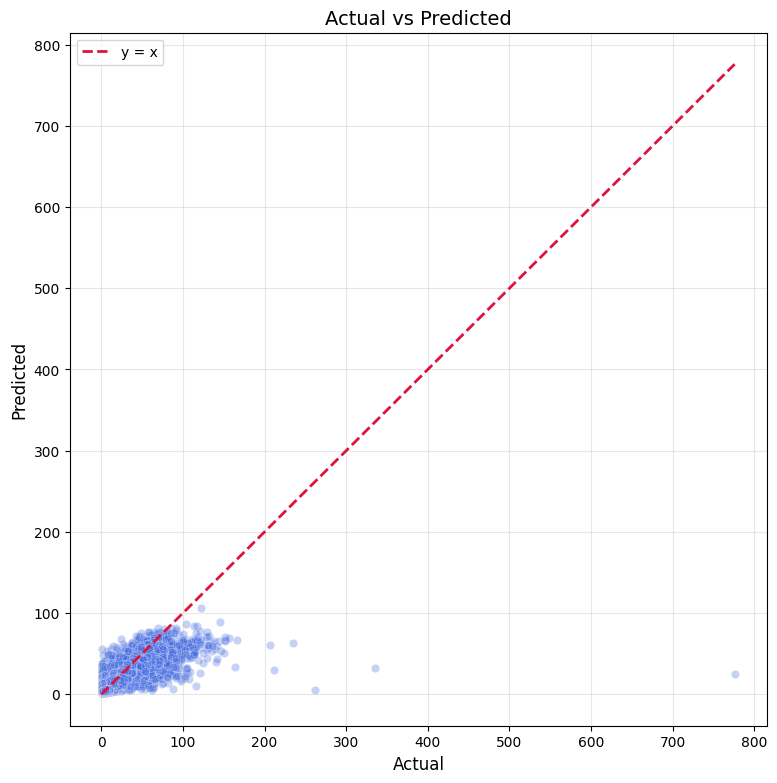

In [12]:
plt.figure(figsize=(9, 9))
sns.scatterplot(data=val_df, x="actual_visitors", y="pred_visitors", alpha=0.3, color="royalblue")

max_val = int(max(val_df["actual_visitors"].max(), val_df["pred_visitors"].max()))
plt.plot([0, max_val], [0, max_val], color="crimson", linestyle="--", linewidth=2, label="y = x")

plt.title("Actual vs Predicted", fontsize=14)
plt.xlabel("Actual", fontsize=12)
plt.ylabel("Predicted", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

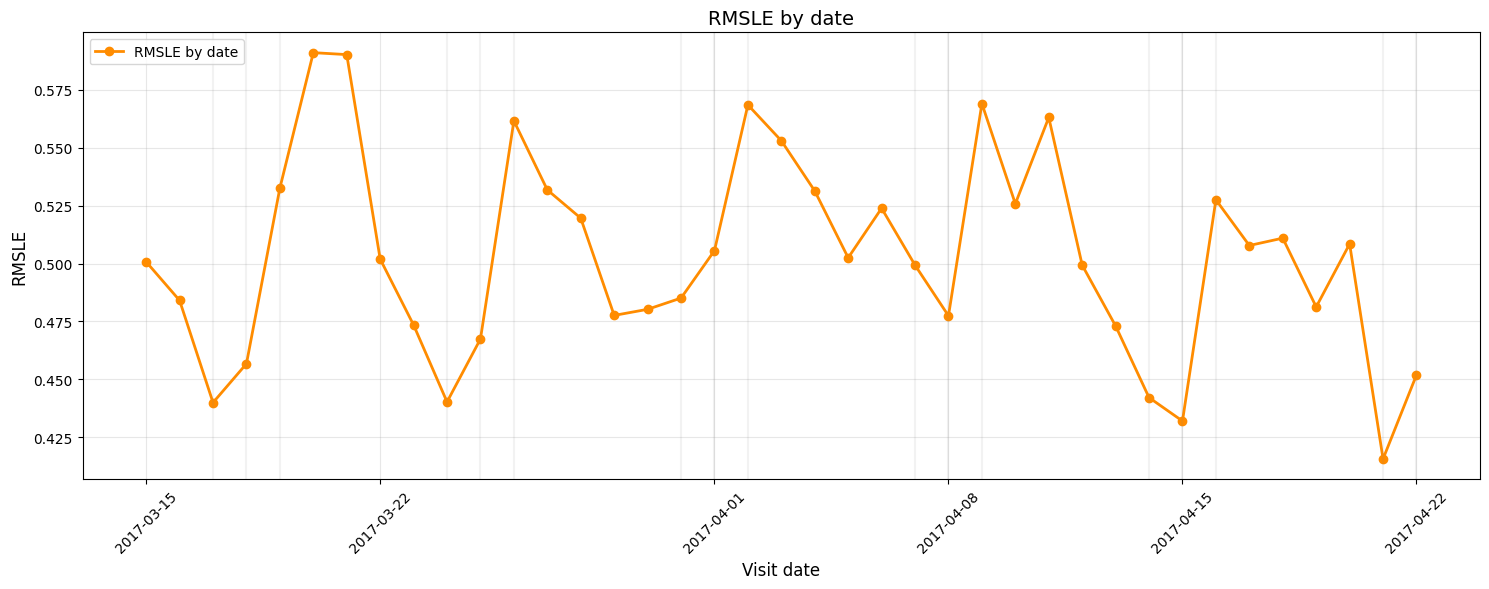

In [13]:
daily_errors = (
    val_df.groupby("visit_date")["squared_log_error"].mean().apply(np.sqrt).reset_index()
)
daily_errors.rename(columns={"squared_log_error": "RMSLE"}, inplace=True)

plt.figure(figsize=(15, 6))
plt.plot(
    daily_errors["visit_date"],
    daily_errors["RMSLE"],
    marker="o",
    color="darkorange",
    linewidth=2,
    label="RMSLE by date",
)

val_df_weekend = val_df[val_df["day_of_week"].isin(["Friday", "Saturday", "Sunday"])]
weekend_dates = val_df_weekend["visit_date"].unique()
for date in weekend_dates:
    plt.axvline(date, color="gray", alpha=0.1, linestyle="-")

plt.title("RMSLE by date", fontsize=14)
plt.xlabel("Visit date", fontsize=12)
plt.ylabel("RMSLE", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_19107/4041725546.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_errors, x="RMSLE", y="air_genre_name", palette="viridis")


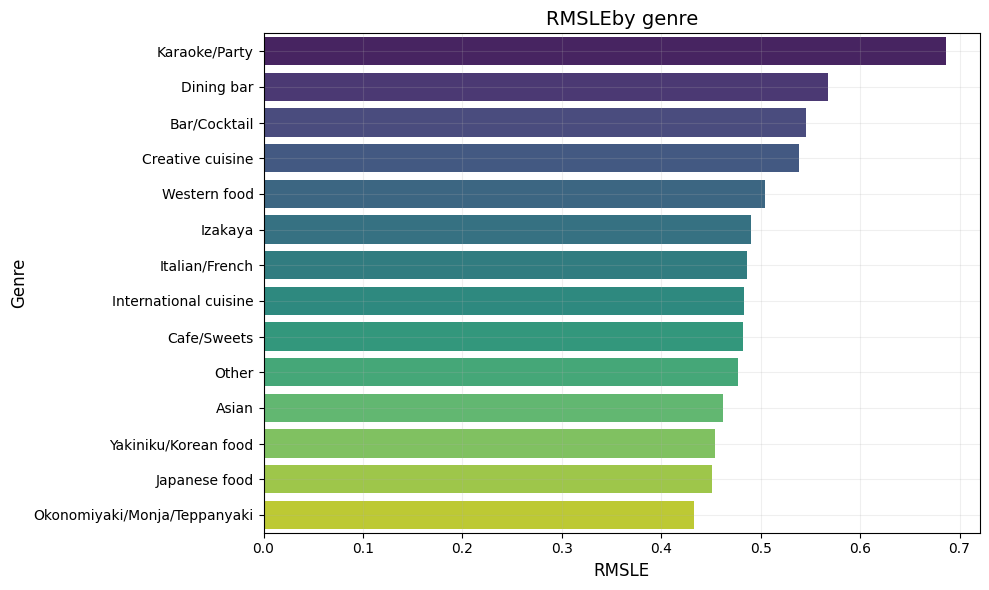

In [14]:
genre_errors = (
    val_df.groupby("air_genre_name")["squared_log_error"].mean().apply(np.sqrt).reset_index()
)
genre_errors.rename(columns={"squared_log_error": "RMSLE"}, inplace=True)
genre_errors = genre_errors.sort_values("RMSLE", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=genre_errors, x="RMSLE", y="air_genre_name", palette="viridis")

plt.title("RMSLEby genre", fontsize=14)
plt.xlabel("RMSLE", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

/tmp/ipykernel_19107/1410716542.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dow_errors, x="day_of_week", y="RMSLE", order=dow_order, palette="muted")


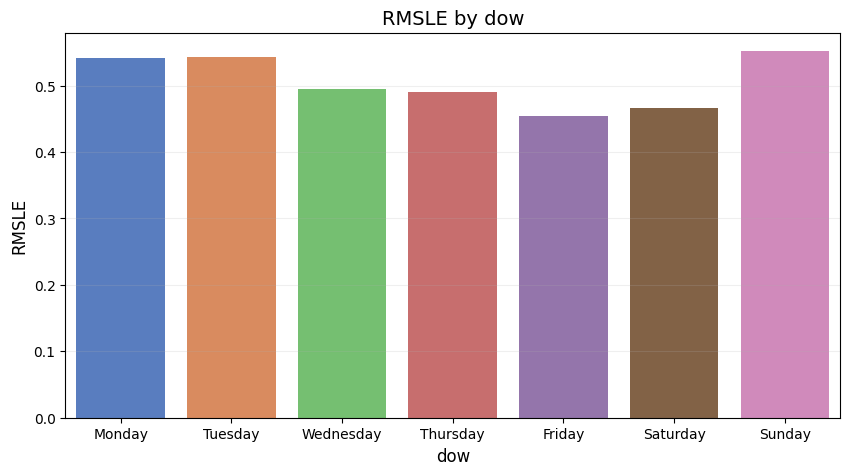

In [15]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dow_errors = val_df.groupby("day_of_week")["squared_log_error"].mean().apply(np.sqrt).reset_index()
dow_errors.rename(columns={"squared_log_error": "RMSLE"}, inplace=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=dow_errors, x="day_of_week", y="RMSLE", order=dow_order, palette="muted")

plt.title("RMSLE by dow", fontsize=14)
plt.xlabel("dow", fontsize=12)
plt.ylabel("RMSLE", fontsize=12)
plt.grid(True, alpha=0.2, axis="y")
plt.show()

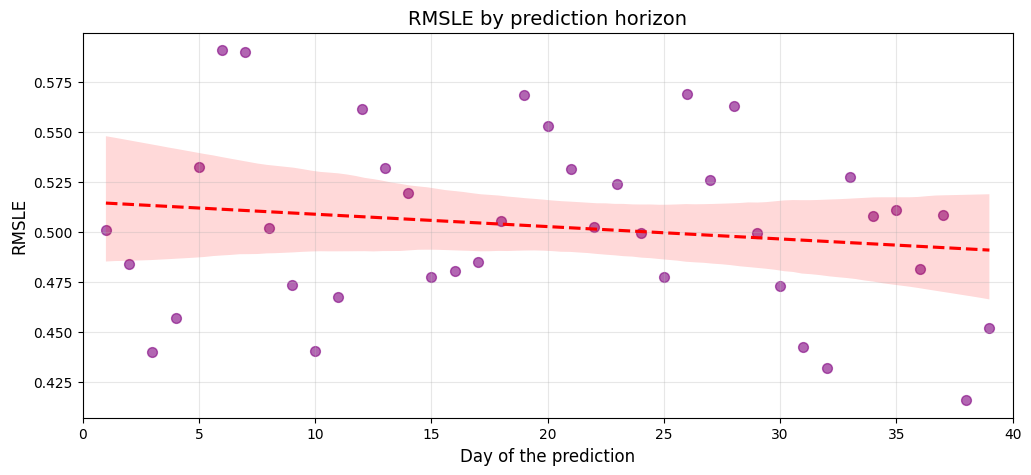

In [16]:
min_val_date = val_df["visit_date"].min()
val_df["forecast_horizon"] = (val_df["visit_date"] - min_val_date).dt.days + 1

horizon_errors = (
    val_df.groupby("forecast_horizon")["squared_log_error"].mean().apply(np.sqrt).reset_index()
)
horizon_errors.rename(columns={"squared_log_error": "RMSLE"}, inplace=True)

plt.figure(figsize=(12, 5))
sns.regplot(
    data=horizon_errors,
    x="forecast_horizon",
    y="RMSLE",
    color="purple",
    scatter_kws={"s": 50, "alpha": 0.6},
    line_kws={"color": "red", "linestyle": "--"},
)

plt.title("RMSLE by prediction horizon", fontsize=14)
plt.xlabel("Day of the prediction", fontsize=12)
plt.ylabel("RMSLE", fontsize=12)
plt.xlim(0, 40)
plt.grid(True, alpha=0.3)
plt.show()

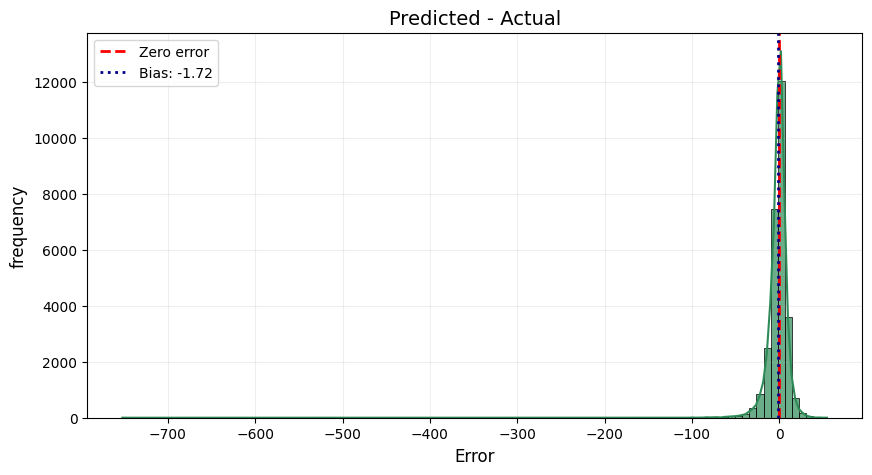

In [17]:
plt.figure(figsize=(10, 5))

sns.histplot(val_df["error"], bins=100, kde=True, color="seagreen", edgecolor="black", alpha=0.7)

plt.axvline(0, color="red", linestyle="--", linewidth=2, label="Zero error")

mean_error = val_df["error"].mean()
plt.axvline(
    mean_error, color="darkblue", linestyle=":", linewidth=2, label=f"Bias: {mean_error:.2f}"
)

plt.title("Predicted - Actual", fontsize=14)
plt.xlabel("Error", fontsize=12)
plt.ylabel("frequency", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()